# Data generation

In [62]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn import svm
import numpy as np
import pickle
import seaborn as sns
import sys
import os

In [66]:
n_cells = 20; # number of cells to simulate
n_stim_type = 2; # number of different stimuli
sigma_stim = 0.5 # amplitude of stimulus related modulation
average_firing_rate = 5; # average firing rate across the population

# generate baseline rates from exponential distirbution
cell_rate_baseline = np.random.exponential(average_firing_rate,size=n_cells)

# create stimulus average responses, perturbing the population firng rate profile
# we use a multiplicative modulation in opposite directions for the two stimuli
modulation = sigma_stim*np.random.normal(0,1,size=n_cells)
cell_rate_stim = {1: cell_rate_baseline * (1+modulation),2:cell_rate_baseline * (1-modulation)}
# sets negative firng rate to 0
cell_rate_stim[1][cell_rate_stim[1]<0]=0
cell_rate_stim[2][cell_rate_stim[2]<0]=0

# simulate spiking activity
s_rate = 10000 # the sampling rate of our emulated recording system
noise_rate = 1 # we are going to add some spike noise non related to the task
n_stim = 100 # number of stimuli

stim_dur = 2 #stimulus duration (in seconds)
is_interval = 3 # interval between stimuli  (in seconds)

stim_onsets = np.arange(0,n_stim*(stim_dur+is_interval),(stim_dur+is_interval)) # onset time of each stimulus (in seconds)
stim_type = np.asarray([1 for i in range(int(n_stim/2))]+[2 for i in range(int(n_stim/2))]) # identity of each stimulus
np.random.shuffle(stim_type)

time = np.arange(0,(n_stim+1)*(stim_dur+is_interval),1.0/s_rate) # vector of the sampled times.

spike_times = []
for cell in range(n_cells):
    spikes = np.random.poisson(cell_rate_baseline[cell]/s_rate,size=time.shape)
    for i,stimulus in enumerate(stim_type):
        stim_idxs = np.arange(stim_onsets[i]*s_rate,(stim_onsets[i]+stim_dur)*s_rate)
        spikes[stim_idxs] = np.random.poisson(cell_rate_stim[stimulus][cell]/s_rate,size=stim_idxs.shape)

    spike_times.append(time[spikes>0])

os.makedirs('data', exist_ok=True)

out_dict = {
    'spike_times': spike_times,
    'stim_onsets': stim_onsets,
    'stim_type': stim_type,
    'stim_duration': stim_dur
}

# Save the data
with open('data/simulated_data1.pickle', 'wb') as handle:
    pickle.dump(out_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Exercise 3

### *2. generation data with different noise amplitude in the firing rate (20x times higher than ref)*

In [67]:
n_cells = 20; # number of cells to simulate
n_stim_type = 2; # number of different stimuli
sigma_stim = 0.5 # amplitude of stimulus related modulation
average_firing_rate = 5; # average firing rate across the population

# generate baseline rates from exponential distirbution
cell_rate_baseline = np.random.exponential(average_firing_rate,size=n_cells)

# create stimulus average responses, perturbing the population firng rate profile
# we use a multiplicative modulation in opposite directions for the two stimuli
modulation = sigma_stim*np.random.normal(0,1,size=n_cells)
cell_rate_stim = {1: cell_rate_baseline * (1+modulation),2:cell_rate_baseline * (1-modulation)}
# sets negative firng rate to 0
cell_rate_stim[1][cell_rate_stim[1]<0]=0
cell_rate_stim[2][cell_rate_stim[2]<0]=0

# simulate spiking activity
s_rate = 10000 # the sampling rate of our emulated recording system
noise_rate = 20 # we are going to add some spike noise non related to the task
n_stim = 100 # number of stimuli

stim_dur = 2 #stimulus duration (in seconds)
is_interval = 3 # interval between stimuli  (in seconds)

stim_onsets = np.arange(0,n_stim*(stim_dur+is_interval),(stim_dur+is_interval)) # onset time of each stimulus (in seconds)
stim_type = np.asarray([1 for i in range(int(n_stim/2))]+[2 for i in range(int(n_stim/2))]) # identity of each stimulus
np.random.shuffle(stim_type)

time = np.arange(0,(n_stim+1)*(stim_dur+is_interval),1.0/s_rate) # vector of the sampled times.

spike_times = []
for cell in range(n_cells):
    spikes = np.random.poisson(cell_rate_baseline[cell]/s_rate,size=time.shape)
    for i,stimulus in enumerate(stim_type):
        stim_idxs = np.arange(stim_onsets[i]*s_rate,(stim_onsets[i]+stim_dur)*s_rate)
        spikes[stim_idxs] = np.random.poisson(cell_rate_stim[stimulus][cell]/s_rate,size=stim_idxs.shape)

    spike_times.append(time[spikes>0])

os.makedirs('data', exist_ok=True)

out_dict = {
    'spike_times': spike_times,
    'stim_onsets': stim_onsets,
    'stim_type': stim_type,
    'stim_duration': stim_dur
}

# Save the data
with open('data/simulated_data2.pickle', 'wb') as handle:
    pickle.dump(out_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)

### *3. generation data with different stimulus modulation amplitude of the firing rate (10x higher than ref)*

In [68]:
n_cells = 20; # number of cells to simulate
n_stim_type = 2; # number of different stimuli
sigma_stim = 5.0 # amplitude of stimulus related modulation
average_firing_rate = 5; # average firing rate across the population

# generate baseline rates from exponential distirbution
cell_rate_baseline = np.random.exponential(average_firing_rate,size=n_cells)

# create stimulus average responses, perturbing the population firng rate profile
# we use a multiplicative modulation in opposite directions for the two stimuli
modulation = sigma_stim*np.random.normal(0,1,size=n_cells)
cell_rate_stim = {1: cell_rate_baseline * (1+modulation),2:cell_rate_baseline * (1-modulation)}
# sets negative firng rate to 0
cell_rate_stim[1][cell_rate_stim[1]<0]=0
cell_rate_stim[2][cell_rate_stim[2]<0]=0

# simulate spiking activity
s_rate = 10000 # the sampling rate of our emulated recording system
noise_rate = 1 # we are going to add some spike noise non related to the task
n_stim = 100 # number of stimuli

stim_dur = 2 #stimulus duration (in seconds)
is_interval = 3 # interval between stimuli  (in seconds)

stim_onsets = np.arange(0,n_stim*(stim_dur+is_interval),(stim_dur+is_interval)) # onset time of each stimulus (in seconds)
stim_type = np.asarray([1 for i in range(int(n_stim/2))]+[2 for i in range(int(n_stim/2))]) # identity of each stimulus
np.random.shuffle(stim_type)

time = np.arange(0,(n_stim+1)*(stim_dur+is_interval),1.0/s_rate) # vector of the sampled times.

spike_times = []
for cell in range(n_cells):
    spikes = np.random.poisson(cell_rate_baseline[cell]/s_rate,size=time.shape)
    for i,stimulus in enumerate(stim_type):
        stim_idxs = np.arange(stim_onsets[i]*s_rate,(stim_onsets[i]+stim_dur)*s_rate)
        spikes[stim_idxs] = np.random.poisson(cell_rate_stim[stimulus][cell]/s_rate,size=stim_idxs.shape)

    spike_times.append(time[spikes>0])

os.makedirs('data', exist_ok=True)

out_dict = {
    'spike_times': spike_times,
    'stim_onsets': stim_onsets,
    'stim_type': stim_type,
    'stim_duration': stim_dur
}

# Save the data
with open('data/simulated_data3.pickle', 'wb') as handle:
    pickle.dump(out_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)

### *4. generation data with different number of neurons (5x lower than ref)*

In [69]:
n_cells = 4; # number of cells to simulate
n_stim_type = 2; # number of different stimuli
sigma_stim = 0.5 # amplitude of stimulus related modulation
average_firing_rate = 5; # average firing rate across the population

# generate baseline rates from exponential distirbution
cell_rate_baseline = np.random.exponential(average_firing_rate,size=n_cells)

# create stimulus average responses, perturbing the population firng rate profile
# we use a multiplicative modulation in opposite directions for the two stimuli
modulation = sigma_stim*np.random.normal(0,1,size=n_cells)
cell_rate_stim = {1: cell_rate_baseline * (1+modulation),2:cell_rate_baseline * (1-modulation)}
# sets negative firng rate to 0
cell_rate_stim[1][cell_rate_stim[1]<0]=0
cell_rate_stim[2][cell_rate_stim[2]<0]=0

# simulate spiking activity
s_rate = 10000 # the sampling rate of our emulated recording system
noise_rate = 1 # we are going to add some spike noise non related to the task
n_stim = 100 # number of stimuli

stim_dur = 2 #stimulus duration (in seconds)
is_interval = 3 # interval between stimuli  (in seconds)

stim_onsets = np.arange(0,n_stim*(stim_dur+is_interval),(stim_dur+is_interval)) # onset time of each stimulus (in seconds)
stim_type = np.asarray([1 for i in range(int(n_stim/2))]+[2 for i in range(int(n_stim/2))]) # identity of each stimulus
np.random.shuffle(stim_type)

time = np.arange(0,(n_stim+1)*(stim_dur+is_interval),1.0/s_rate) # vector of the sampled times.

spike_times = []
for cell in range(n_cells):
    spikes = np.random.poisson(cell_rate_baseline[cell]/s_rate,size=time.shape)
    for i,stimulus in enumerate(stim_type):
        stim_idxs = np.arange(stim_onsets[i]*s_rate,(stim_onsets[i]+stim_dur)*s_rate)
        spikes[stim_idxs] = np.random.poisson(cell_rate_stim[stimulus][cell]/s_rate,size=stim_idxs.shape)

    spike_times.append(time[spikes>0])

os.makedirs('data', exist_ok=True)

out_dict = {
    'spike_times': spike_times,
    'stim_onsets': stim_onsets,
    'stim_type': stim_type,
    'stim_duration': stim_dur
}

# Save the data
with open('data/simulated_data4.pickle', 'wb') as handle:
    pickle.dump(out_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [70]:
data_files = [
    'data/simulated_data1.pickle',
    'data/simulated_data2.pickle',
    'data/simulated_data3.pickle',
    'data/simulated_data4.pickle'
]

In [71]:
import pickle
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn import svm

# parameters
binwidth = 0.1  # in seconds (100 ms)
onset = 1  # 1 second before stimulus onset
offset = 1  # 1 second after stimulus offset
bins = np.arange(-onset, stim_duration + offset + binwidth, binwidth)

n_splits = 5

# empty list
all_performances = []
all_std = []

#looping through the four files
for file in data_files:
    with open(file, 'rb') as handle:
        data = pickle.load(handle)

    spike_times = data['spike_times']
    stim_onsets = data['stim_onsets']
    stim_type = data['stim_type']
    stim_duration = data['stim_duration']

    #bin data
    n_cells = len(spike_times)
    print(f"  - Number of neurons (n_cells): {n_cells}")
    n_trials = len(stim_type)
    X = np.zeros((n_cells, n_trials, len(bins) - 1))

    for cell in range(n_cells):
            for trial in range(n_trials):
                sp_idx = np.logical_and(
                    spike_times[cell] > stim_onsets[trial] - onset,
                    spike_times[cell] < stim_onsets[trial] + stim_duration + offset
                )
                sp_cntr = spike_times[cell][sp_idx] - stim_onsets[trial]
                spike_count, _ = np.histogram(sp_cntr, bins)
                X[cell, trial, :] = spike_count
                
    avg_performance = []
    std_performance = []
    for time_bin in range(X.shape[-1]):
        kf = StratifiedKFold(n_splits = n_splits, shuffle = True)
        fold_performance = []
        
        for train_index, test_index in kf.split(X[:, :, time_bin].T, stim_type):
            X_train, X_test = X[:, train_index, time_bin].T, X[:, test_index, time_bin].T
            y_train, y_test = stim_type[train_index], stim_type[test_index]
            clf = svm.LinearSVC(max_iter=1000)
            clf.fit(X_train, y_train)
            fold_performance.append(clf.score(X_test, y_test))
        
        avg_performance.append(np.mean(fold_performance))
        std_performance.append(np.std(fold_performance))
        
    all_performances.append(avg_performance)
    all_std.append(avg_performance)

  - Number of neurons (n_cells): 20
  - Number of neurons (n_cells): 20
  - Number of neurons (n_cells): 20
  - Number of neurons (n_cells): 4


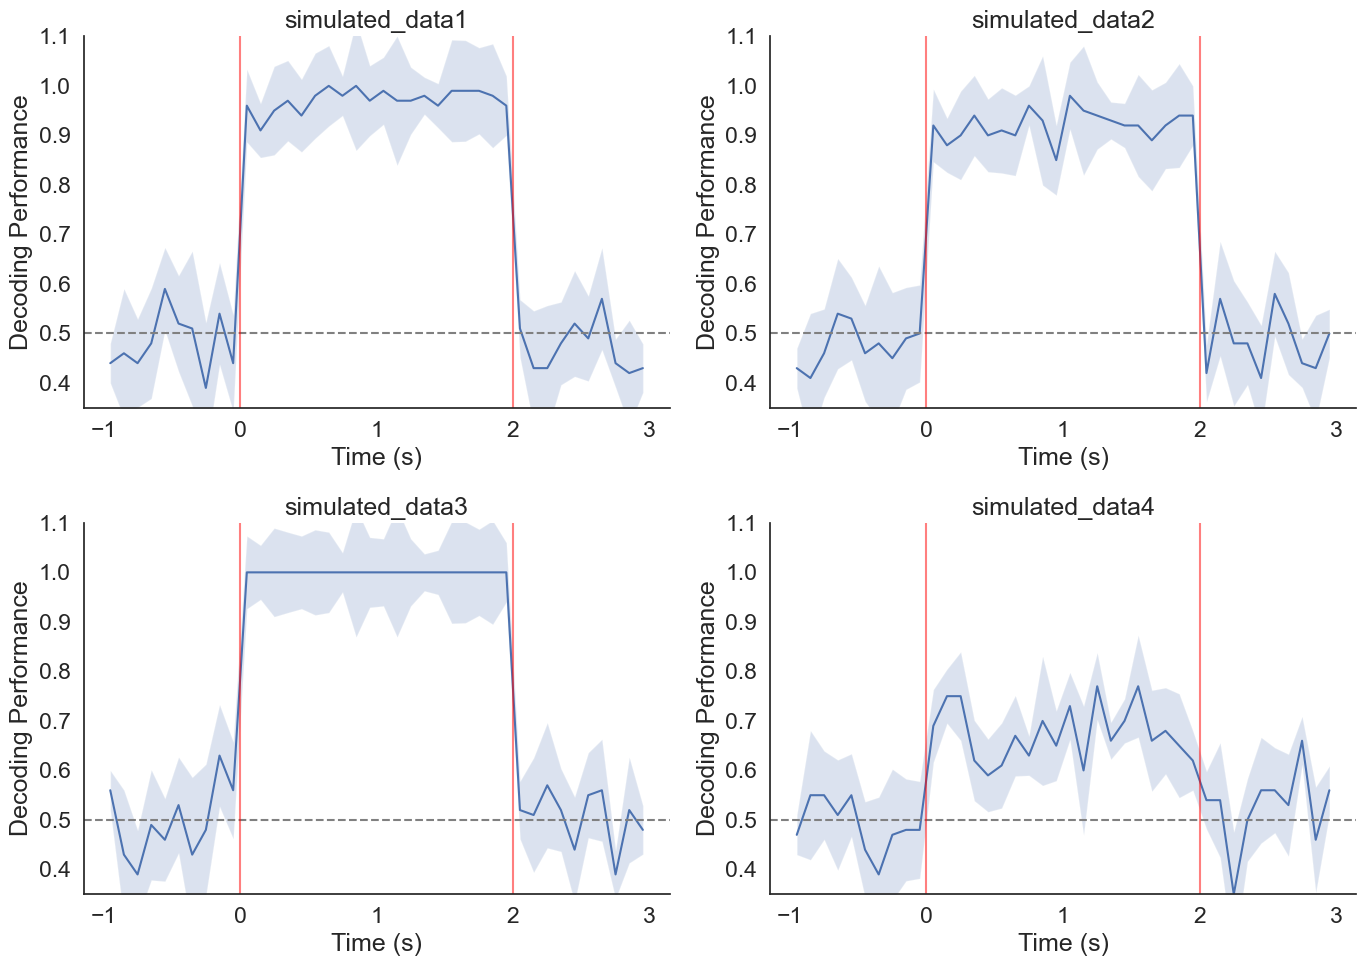

In [72]:
import matplotlib.pyplot as plt

# Define bin centers for the x-axis
bin_centers = [(bins[i + 1] + bins[i]) / 2 for i in range(len(bins) - 1)]

# Create a figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot each file's performance in a subplot
for i, (file, performance) in enumerate(zip(data_files, all_performances)):
    performance = np.array(performance)
    std_performance = np.array(std_performance)
    
    ax = axes[i // 2, i % 2]
    ax.plot(bin_centers, performance, label='Decoding Performance')
    ax.fill_between(bin_centers, performance - std_performance, performance + std_performance, alpha=0.2)
    
    ax.axhline(y=0.5, linestyle='--', color='gray', label='Chance Level')
    ax.axvline(x=0, color='red', linestyle='-', alpha=0.5)
    ax.axvline(x=stim_duration, color='red', linestyle='-', alpha=0.5)
    ax.set_title(f'{file.split("/")[-1].split(".")[0]}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Decoding Performance')
    ax.set_ylim(0.35, 1.1)

plt.tight_layout()
plt.show()

# Exercise 3 comments
subplot 1 (simulated_data1) displays the performance of the decoder on the reference data (generated with the code given), subplot 2 (simulated_data2) is the data with altered amplitude of the noise in the firing rate, subplot 3 (simulated_data3) is the data with altered amplitude of the stimulus modulation of the firing rate and subplot 4 (simulated_data4) is the data with altered number of neurons.

With a higher noise amplitude, the decoding performance between time 0 and 2 seconds is slightly lower than ref, being more around decoding performance 0.9. So noise decreases decoidng performance

With a higher amplitude of stimulus modulation of th efiring rate, the decoding performance increases to 1 between time is 0-2 seconds, the subplot displaying a ceiling at 1.0 decoding performance. the high stimulus modulation makes it easier for the model to distinguish between two stimuli.

with less neurons, the decoding performance decreases to between 0.60-0.75. less neurons is less information, giving the model less input. with more neurons than ref, the decoding performance likely rises compared to ref.